In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

In [2]:
df = pd.read_csv('Data_Files/dropdown_df.csv')

In [136]:
mewtwo = df[df['Decklists'].str.contains('Mewtwo ex')].copy()

In [250]:
expansion = []
exp_dates = [datetime.date.strptime(date, "%Y-%m-%d") for date in ['2024-12-17', '2025-1-30', '2025-2-28', '2025-3-27', '2025-4-30',
                                                               '2025-5-29', '2025-6-25', '2025-7-30', '2025-8-28']]
for date in df['Date']:
    date = datetime.date.strptime(date, "%Y-%m-%d")
    if date < exp_dates[0]:
        expansion.append('Genetic Apex')
    elif exp_dates[0] <= date < exp_dates[1]:
        expansion.append('Mythical Island')
    elif exp_dates[1] <= date < exp_dates[2]:
        expansion.append('Space-Time Smackdown')
    elif exp_dates[2] <= date < exp_dates[3]:
        expansion.append('Triumphant Light')
    elif exp_dates[3] <= date < exp_dates[4]:
        expansion.append('Shining Revelry')
    elif exp_dates[4] <= date < exp_dates[5]:
        expansion.append('Celestial Guardians')
    elif exp_dates[5] <= date < exp_dates[6]:
        expansion.append('Extradimensional Crisis')
    elif exp_dates[6] <= date < exp_dates[7]:
        expansion.append('Eevee Grove')
    elif exp_dates[7] <= date < exp_dates[8]:
        expansion.append('Wisdom of Sea and Sky')
    else:
        expansion.append('Secluded Springs')

In [139]:
mewtwo['Expansion'] = expansion

In [170]:
for expansion in mewtwo['Expansion'].unique():
    print(len(mewtwo[(mewtwo['Player_Total'] > 100) & (mewtwo['Expansion'] == expansion)]))

202
170
113
83
71
70
21
36
23
13


In [175]:
mewtwo[Placement'].mean()

np.float64(207.9197224975223)

In [178]:
for expansion in mewtwo['Expansion'].unique():
    print(mewtwo[mewtwo['Expansion'] == expansion]['Placement'].mean())

248.80803571428572
214.60199004975124
262.4
216.62105263157895
130.25263157894736
231.34408602150538
273.75757575757575
155.44444444444446
61.09375
56.92307692307692


In [247]:
test = pd.DataFrame({'Expansion':mewtwo['Expansion'].unique(),'Placement':[mewtwo[(mewtwo['Expansion'] == expansion) & (mewtwo['Player_Total'] > 100)]['Placement'].sort_values()[:30].mean() for expansion in mewtwo['Expansion'].unique()]})

In [248]:
test

,Expansion,Placement
0,Genetic Apex,3.433333
1,Mythical Island,5.100000
2,Space-Time Smackdown,24.800000
3,Triumphant Light,32.366667
4,Shining Revelry,23.533333
5,Celestial Guardians,55.100000
6,Extradimensional Crisis,420.190476
7,Eevee Grove,148.733333
8,Wisdom of Sea and Sky,71.130435
9,Secluded Springs,153.692308


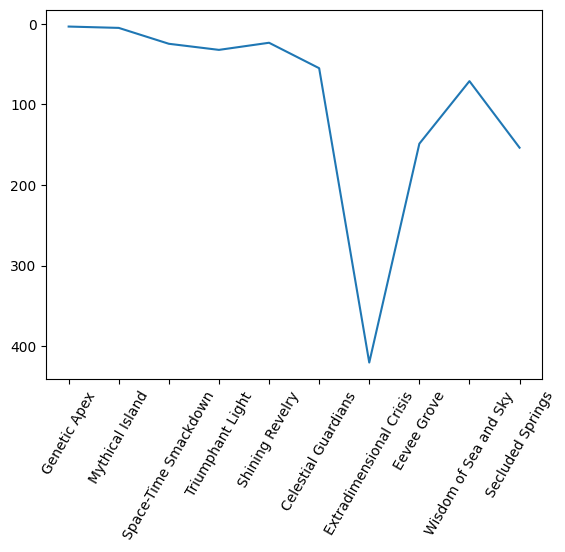

In [410]:
fig, ax = plt.subplots()
ax.plot(test['Expansion'],test['Placement'])
ax.tick_params(axis='x',labelrotation=60)
ax.invert_yaxis()

In [251]:
df['Expansion'] = expansion

In [253]:
df.to_csv('Data_Files/dropdown_df.csv',index=False)

In [280]:
with open('Data_Files/names.txt', 'r') as f:
    names = [line.strip() for line in f]

In [393]:
names.index('Starmie ex')

72

In [395]:
df1 = df[df['Decklists'].str.contains(names[72])]
print(df1.head(1)['Deck'])

120    Starmie ex Articuno ex
Name: Deck, dtype: object


In [398]:
stats = df1[(df1['Player_Total'] > 300) & (df1['Placement'] <= 10)]
print(len(stats))
print(stats.head()[['Deck','Tournament','Placement','Player_Total']])


# comment

17
                       Deck  \
121  Starmie ex Articuno ex   
124  Starmie ex Articuno ex   
127  Starmie ex Articuno ex   
128  Starmie ex Articuno ex   
134  Starmie ex Articuno ex   

                                            Tournament  Placement  \
121                        Pocket Ditto #1! ($80 Cash)        3.0   
124    Beanie Brawl - Pocket Edition - $100 Prize Pool        3.0   
127           Pikaverse Pocket Cup #4 • $100 USD Prize        8.0   
128  $500 ADVANCEDgg - 12 Days of Christmas TCG Pocket        6.0   
134             Pokémon Millennium Pocket Free Tour #1        6.0   

     Player_Total  
121         528.0  
124         351.0  
127         871.0  
128         647.0  
134         458.0  
